In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules.gmp_ar_model import GMP_AR
from modules.moe_ar_gmp_model import MoE_GMP_AR

from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
# from modules.gmp_model import GMP
import matplotlib.pyplot as plt
import numpy as np
import torch



Load data from files and init acpr meter

In [3]:
data = data_loader.load_data("DPA_200MHz")

config = data["config"]
fs = config["input_signal_fs"]
bw_main_ch = config["bw_main_ch"]
bw_sub_ch = config["bw_sub_ch"]
n_sub_ch = config["n_sub_ch"]
sub_ch = config["sub_ch"]
nperseg = config["nperseg"]

x_train = data["train_input"]
y_train = data["train_output"]
x_val = data["val_input"]
y_val = data["val_output"]

gain = metrics.calculate_gain_complex(x_train, y_train)
print(f"Gain of PA = {gain:.2f}")
y_train_target = gain * x_train
y_val_target = gain * x_val

data['y_train_target'] = y_train_target
data['y_val_target'] = y_val_target


acpr_meter = metrics.ACPR(
        sample_rate=fs,
        main_measurement_bandwidth=bw_main_ch,
        adjacent_channel_offset=[-sub_ch, sub_ch],
        segment_length=nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


Gain of PA = 2.52


PA model

In [25]:
pa_train_loader = [(x_train, y_train)]
pa_val_loader = [(x_val, y_val)]
# pa_val_loader = pa_train_loader

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse

Ka=La=Kb=Lb=Mb=Kc=Lc=Mc=Dy=5

pa_model = GMP_AR(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, Dy, model_name="pa")

epochs = 10000
lr = 0.00001

optimizer = torch.optim.Adam(pa_model.parameters(), lr=lr)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion, 
            optimizer=optimizer,  
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion)
      pa_model.save_weights()
utils.freeze_pa_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=x_val)
pa_nmse = metrics.compute_nmse(y_val_pa, y_val)
print(f"Model NMSE: {pa_nmse:.2f}")

model_params/pa_ar_gmp_model_Ka5_La5_Kb5_Lb5_Mb5_Kc5_Lc5_Mc5_Dy5.pt
Coefficients loaded from model_params/pa_ar_gmp_model_Ka5_La5_Kb5_Lb5_Mb5_Kc5_Lc5_Mc5_Dy5.pt
===Start training===
Epoch 0000 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.42
Epoch 0001 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0002 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0003 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0004 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0005 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0006 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0007 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0008 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0009 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0010 — train_loss: 0.000435, val_loss: 0.000446, val_NMSE: -34.41
Epoch 0011 — train_loss: 0

In [21]:
pa_model.count_params()

280

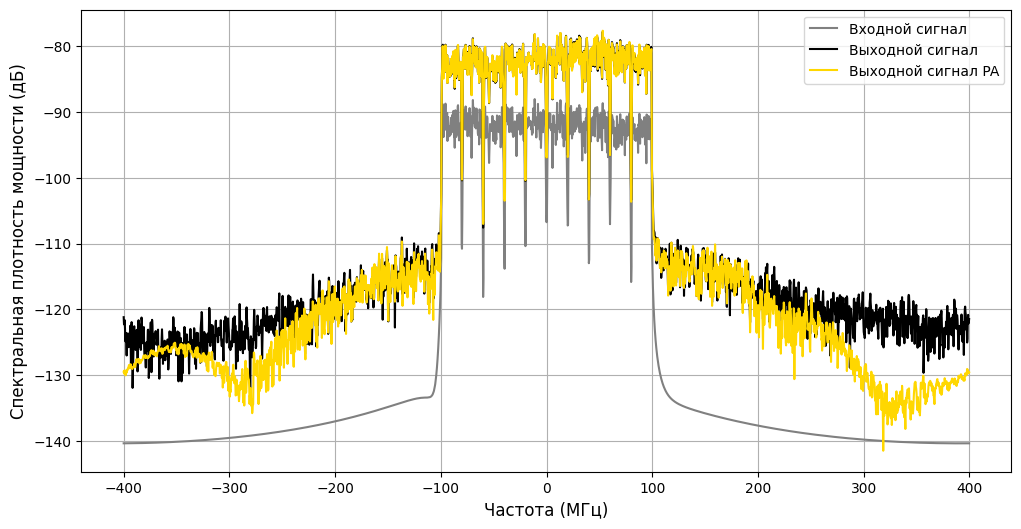

In [26]:
freqs, spectrum_y_in = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_out = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_in)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_out)), color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_pa)), color='gold', label='Выходной сигнал PA')

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


DLA DPD grad

In [7]:
dla_train_loader = [(x_train, y_train_target)]
dla_val_loader = [(x_val, y_val_target)]
# dla_val_loader = dla_train_loader

epochs = 500
lr = 0.01

Ka=La=Kb=Lb=Mb=Kc=Lc=Mc=2
Dy=5

dpd_model_dla = GMP_AR(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, Dy, model_name="dla")

is_load = dpd_model_dla.load_weights()
casc_dla = utils.CascadeModel(model_1=dpd_model_dla, model_2=pa_model)

optimizer_dla = torch.optim.Adam(casc_dla.parameters(), lr=lr)

if not is_load:
    learning.train(net=casc_dla, 
                   criterion=criterion, 
                   optimizer=optimizer_dla, 
                   train_loader=dla_train_loader, 
                   val_loader=dla_val_loader, 
                   grad_clip_val=0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    dpd_model_dla.save_weights()

y_val_dla = learning.net_inference(net=casc_dla, x=x_val)
nmse_dla = metrics.compute_nmse(y_val_dla, y_val_target)
print(f"Model NMSE: {nmse_dla:.2f}")



No saved coefficients found at model_params/dla_ar_gmp_model_Ka2_La2_Kb2_Lb2_Mb2_Kc2_Lc2_Mc2_Dy5.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.380712, val_loss: 0.321506, val_NMSE: -3.85
Epoch 0001 — train_loss: 0.313244, val_loss: 0.256475, val_NMSE: -4.83
Epoch 0002 — train_loss: 0.249875, val_loss: 0.197984, val_NMSE: -5.95
Epoch 0003 — train_loss: 0.193340, val_loss: 0.148604, val_NMSE: -7.20
Epoch 0004 — train_loss: 0.145749, val_loss: 0.107574, val_NMSE: -8.60
Epoch 0005 — train_loss: 0.106022, val_loss: 0.074899, val_NMSE: -10.18
Epoch 0006 — train_loss: 0.074118, val_loss: 0.051397, val_NMSE: -11.81
Epoch 0007 — train_loss: 0.050993, val_loss: 0.036783, val_NMSE: -13.26
Epoch 0008 — train_loss: 0.036551, val_loss: 0.029519, val_NMSE: -14.22
Epoch 0009 — train_loss: 0.029384, val_loss: 0.028037, val_NMSE: -14.44
Epoch 0010 — train_loss: 0.027929, val_loss: 0.030848, val_NMSE: -14.03
Epoch 0011 — train_loss: 0.030682, val_loss: 0.035802, val_NMS

ILA DPD grad

In [8]:
ila_train_loader = [(x_train, x_train)]
ila_val_loader = [(x_val, x_val)]

epochs = 500
lr = 0.01

Ka=La=Kb=Lb=Mb=Kc=Lc=Mc=2
Dy=5

dpd_model_ila = GMP_AR(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, Dy, model_name="ila")

is_load = dpd_model_ila.load_weights()
casc_ila_train = utils.CascadeModel(model_2=dpd_model_ila, model_1=pa_model, gain=gain, cascade_type="ila")
casc_ila_eval = utils.CascadeModel(model_1=dpd_model_ila, model_2=pa_model)

optimizer = torch.optim.Adam(casc_ila_train.parameters(), lr=lr)

if not is_load:
    learning.train(net=casc_ila_train, 
                   criterion=criterion, 
                   optimizer=optimizer, 
                   train_loader=ila_train_loader, 
                   val_loader=ila_val_loader, 
                   grad_clip_val=0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    dpd_model_ila.save_weights()

y_val_ila = learning.net_inference(net=casc_ila_eval, x=x_val)
nmse_ila = metrics.compute_nmse(y_val_ila, y_val_target)
print(f"Model NMSE: {nmse_ila:.2f}")


No saved coefficients found at model_params/ila_ar_gmp_model_Ka2_La2_Kb2_Lb2_Mb2_Kc2_Lc2_Mc2_Dy5.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.059954, val_loss: 0.050699, val_NMSE: -3.84
Epoch 0001 — train_loss: 0.049422, val_loss: 0.040479, val_NMSE: -4.82
Epoch 0002 — train_loss: 0.039488, val_loss: 0.031374, val_NMSE: -5.92
Epoch 0003 — train_loss: 0.030636, val_loss: 0.023284, val_NMSE: -7.22
Epoch 0004 — train_loss: 0.022727, val_loss: 0.016569, val_NMSE: -8.70
Epoch 0005 — train_loss: 0.016150, val_loss: 0.011270, val_NMSE: -10.37
Epoch 0006 — train_loss: 0.011000, val_loss: 0.007352, val_NMSE: -12.23
Epoch 0007 — train_loss: 0.007239, val_loss: 0.004955, val_NMSE: -13.94
Epoch 0008 — train_loss: 0.004967, val_loss: 0.004062, val_NMSE: -14.80
Epoch 0009 — train_loss: 0.004132, val_loss: 0.004356, val_NMSE: -14.50
Epoch 0010 — train_loss: 0.004406, val_loss: 0.005366, val_NMSE: -13.59
Epoch 0011 — train_loss: 0.005350, val_loss: 0.006554, val_NMS

ILC DPD grad

In [9]:
u_k_train = learning.ilc_signal(x_train, y_train_target, pa_model, epochs=1000, learning_rate=0.001)
u_k_val = learning.ilc_signal(x_val, y_val_target, pa_model, epochs=1000, learning_rate=0.001)
u_k_pa = pa_model.forward(u_k_train).detach()

data["ilc_train_output"] = u_k_train
data["ilc_val_output"] = u_k_val

ilc_train_loader = [(x_train, u_k_train)]
ilc_val_loader = [(x_val, u_k_val)]

Epoch [0/1000], Loss: 0.030073704198002815
Epoch [100/1000], Loss: 0.0010042866924777627
Epoch [200/1000], Loss: 3.2134448701981455e-05
Epoch [300/1000], Loss: 9.77829245130124e-07
Epoch [400/1000], Loss: 2.5822439297940036e-08
Epoch [500/1000], Loss: 6.061263713164067e-10
Epoch [600/1000], Loss: 1.2591887602053653e-11
Epoch [700/1000], Loss: 3.272889771699372e-13
Epoch [800/1000], Loss: 1.1176462180869859e-13
Epoch [900/1000], Loss: 9.86024887498875e-14
Epoch [999/1000], Loss: 8.913928758536374e-14
Время расчёта ilc_signal: 0:00:24
Epoch [0/1000], Loss: 0.029748056083917618
Epoch [100/1000], Loss: 0.0009979623137041926
Epoch [200/1000], Loss: 3.4588705602800474e-05
Epoch [300/1000], Loss: 1.167852360595134e-06
Epoch [400/1000], Loss: 3.675803483815798e-08
Epoch [500/1000], Loss: 1.0836970210093e-09
Epoch [600/1000], Loss: 2.7841458305477573e-11
Epoch [700/1000], Loss: 6.501757682589315e-13
Epoch [800/1000], Loss: 1.1699502315293958e-13
Epoch [900/1000], Loss: 1.0945222186269435e-13
Ep

In [12]:
epochs = 500
lr = 0.01

Ka=La=Kb=Lb=Mb=Kc=Lc=Mc=2
Dy=5

dpd_model_ilc = GMP_AR(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, Dy, model_name="ilc")

is_load = dpd_model_ilc.load_weights()
optimizer = torch.optim.Adam(dpd_model_ilc.parameters(), lr=lr)

if not is_load:
    learning.train(net=dpd_model_ilc, 
                   criterion=criterion, 
                   optimizer=optimizer, 
                   train_loader=ilc_train_loader, 
                   val_loader=ilc_val_loader, 
                   grad_clip_val=0, 
                   n_epochs=epochs, 
                   metric_criterion=metric_criterion)
    dpd_model_ilc.save_weights()

casc_ilc_eval = utils.CascadeModel(model_1=dpd_model_ilc, model_2=pa_model)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val)
nmse_ilc = metrics.compute_nmse(y_val_ilc, y_val_target)
print(f"Model NMSE: {nmse_ilc:.2f}")


No saved coefficients found at model_params/ilc_ar_gmp_model_Ka2_La2_Kb2_Lb2_Mb2_Kc2_Lc2_Mc2_Dy5.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.037719, val_loss: 0.032390, val_NMSE: -3.80
Epoch 0001 — train_loss: 0.031489, val_loss: 0.026284, val_NMSE: -4.70
Epoch 0002 — train_loss: 0.025625, val_loss: 0.020631, val_NMSE: -5.76
Epoch 0003 — train_loss: 0.020179, val_loss: 0.015597, val_NMSE: -6.97
Epoch 0004 — train_loss: 0.015320, val_loss: 0.011348, val_NMSE: -8.35
Epoch 0005 — train_loss: 0.011213, val_loss: 0.008022, val_NMSE: -9.86
Epoch 0006 — train_loss: 0.007987, val_loss: 0.005671, val_NMSE: -11.36
Epoch 0007 — train_loss: 0.005679, val_loss: 0.004202, val_NMSE: -12.67
Epoch 0008 — train_loss: 0.004203, val_loss: 0.003464, val_NMSE: -13.51
Epoch 0009 — train_loss: 0.003432, val_loss: 0.003266, val_NMSE: -13.76
Epoch 0010 — train_loss: 0.003199, val_loss: 0.003404, val_NMSE: -13.58
Epoch 0011 — train_loss: 0.003315, val_loss: 0.003687, val_NMSE

Metrics

In [13]:
nmse_after_pa = metrics.compute_nmse(y_val_pa, y_val_target)

print(f"NMSE на выходе усилителя (без DPD): {nmse_after_pa:.2f} db")

print(f"NMSE на выходе усилителя (DLA DPD): {nmse_dla:.2f} db")

print(f"NMSE на выходе усилителя (ILA DPD): {nmse_ila:.2f} db")

print(f"NMSE на выходе усилителя (ILC DPD): {nmse_ilc:.2f} db")

NMSE на выходе усилителя (без DPD): -14.19 db
NMSE на выходе усилителя (DLA DPD): -42.23 db
NMSE на выходе усилителя (ILA DPD): -41.93 db
NMSE на выходе усилителя (ILC DPD): -42.22 db


In [14]:
x_val_acpr = metrics.calculate_acpr(x_val, acpr_meter)
y_val_acpr = metrics.calculate_acpr(y_val, acpr_meter)
y_val_pa_acpr = metrics.calculate_acpr(y_val_pa, acpr_meter)
y_val_target_acpr = metrics.calculate_acpr(y_val_target, acpr_meter)

y_lin_dla_acpr = metrics.calculate_acpr(y_val_dla, acpr_meter)
y_lin_ila_acpr = metrics.calculate_acpr(y_val_ila, acpr_meter)
y_lin_ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)

print(f"x_val_acpr: {x_val_acpr}")
print(f"y_val_acpr: {y_val_acpr}")
print(f"y_val_pa_acpr: {y_val_pa_acpr}")
print(f"y_val_target_acpr: {y_val_target_acpr}")

print(f"lin_dla_acpr: {y_lin_dla_acpr}")
print(f"lin_ila_acpr: {y_lin_ila_acpr}")
print(f"lin_ilc_acpr: {y_lin_ilc_acpr}")


x_val_acpr: [-48.08083195 -48.40122574]
y_val_acpr: [-40.60778184 -38.20237847]
y_val_pa_acpr: [-47.90994789 -40.86315851]
y_val_target_acpr: [-48.08083304 -48.40122404]
lin_dla_acpr: [-47.28991219 -48.43640929]
lin_ila_acpr: [-48.4946462  -48.29818163]
lin_ilc_acpr: [-48.72345212 -46.68370908]


In [15]:
nmse_uk_pa = metrics.compute_nmse(u_k_pa, y_train_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

u_k_acpr = metrics.calculate_acpr(u_k_val, acpr_meter)
u_k_pa_acpr = metrics.calculate_acpr(u_k_pa, acpr_meter)

print(f"u_k_acpr: {u_k_acpr}")
print(f"u_k_pa_acpr: {u_k_pa_acpr}")

NMSE на выходе усилителя (ILC): -129.33 db
u_k_acpr: [-43.85634664 -45.46513408]
u_k_pa_acpr: [-50.93608194 -50.3696735 ]


Spectrum

In [16]:
freqs, spectrum_y_in = metrics.power_spectrum(x_val, fs, nperseg)
_, spectrum_y_out = metrics.power_spectrum(y_val, fs, nperseg)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, fs, nperseg)
_, spectrum_y_val_target = metrics.power_spectrum(y_val_target, fs, nperseg)

# _, spectrum_y_dpd_dla = metrics.power_spectrum(y_dpd_dla, fs, nperseg)
# _, spectrum_y_dpd_ila = metrics.power_spectrum(y_dpd_ila, fs, nperseg)
# _, spectrum_y_dpd_ilc = metrics.power_spectrum(y_dpd_ilc, fs, nperseg)

_, spectrum_y_val_dla = metrics.power_spectrum(y_val_dla, fs, nperseg)
_, spectrum_y_val_ila = metrics.power_spectrum(y_val_ila, fs, nperseg)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, fs, nperseg)


# _, spectrum_u_k = metrics.power_spectrum(u_k_val, fs, nperseg)
# _, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, fs, nperseg)

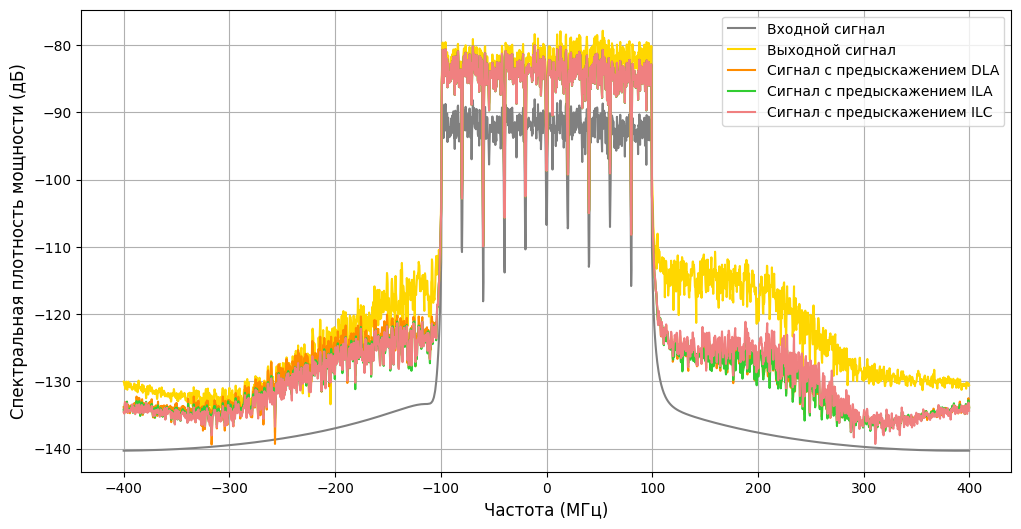

In [17]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_in)), color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_pa)), color='gold', label='Выходной сигнал')
# plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa)), color='red', label='Оптимальный сигнал ILC')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_dla)), color='darkorange', label='Сигнал с предыскажением DLA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_ila)), color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, 10 * np.log10(np.abs(spectrum_y_val_ilc)), color='lightcoral', label='Сигнал с предыскажением ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()



In [18]:
# moving_average
window_size = 60

freqs_s, spectrum_y_in_s = utils.moving_average(spectrum_y_in, freqs, fs, window_size)
_, spectrum_y_out_s = utils.moving_average(spectrum_y_out, freqs, fs, window_size)
_, spectrum_y_val_pa_s = utils.moving_average(spectrum_y_val_pa, freqs, fs, window_size)
_, spectrum_y_val_target_s = utils.moving_average(spectrum_y_val_target, freqs, fs, window_size)

# _, spectrum_y_val_dla_s = utils.moving_average(spectrum_y_val_dla, freqs, fs, window_size)
# _, spectrum_y_val_ila_s = utils.moving_average(spectrum_y_val_ila, freqs, fs, window_size)
# _, spectrum_y_dpd_ilc_grad_s = utils.moving_average(spectrum_y_dpd_ilc_grad, freqs, fs, window_size)

_, spectrum_y_val_dla_s = utils.moving_average(spectrum_y_val_dla, freqs, fs, window_size)
_, spectrum_y_val_ila_s = utils.moving_average(spectrum_y_val_ila, freqs, fs, window_size)
_, spectrum_y_val_ilc_s = utils.moving_average(spectrum_y_val_ilc, freqs, fs, window_size)

# _, spectrum_u_k_s = utils.moving_average(spectrum_u_k, freqs, fs, window_size)
# _, spectrum_u_k_pa_s = utils.moving_average(spectrum_u_k_pa, freqs, fs, window_size)



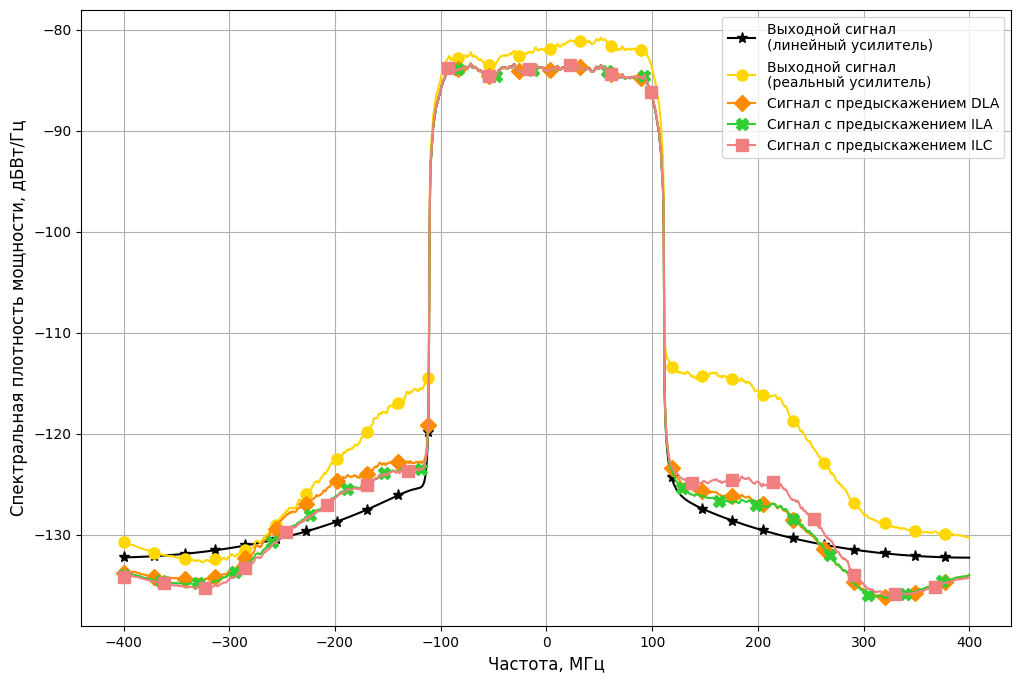

In [19]:
# (сглаженный) построение спектра

xlabel="Частота, МГц"
ylabel= "Спектральная плотность мощности, дБВт/Гц"
fontsize = 12
figsize=(12, 8)
markersize=8

plt.figure(figsize=figsize)

# plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_in_s)), 
#          color='grey', label='Входной сигнал',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_target_s)), 
         color='black', label='Выходной сигнал\n(линейный усилитель)',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_pa_s)), 
         color='gold', label='Выходной сигнал\n(реальный усилитель)', marker='o', markevery=90, markersize=markersize)
# plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa_s)), 
#          color='red', label='Оптимальный сигнал ILC', marker='v', markevery=95, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_dla_s)), 
         color='darkorange', label='Сигнал с предыскажением DLA', marker='D', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_ila_s)), 
         color='limegreen', label='Сигнал с предыскажением ILA', marker='X', markevery=110, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_ilc_s)), 
         color='lightcoral', label='Сигнал с предыскажением ILC', marker='s', markevery=120, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


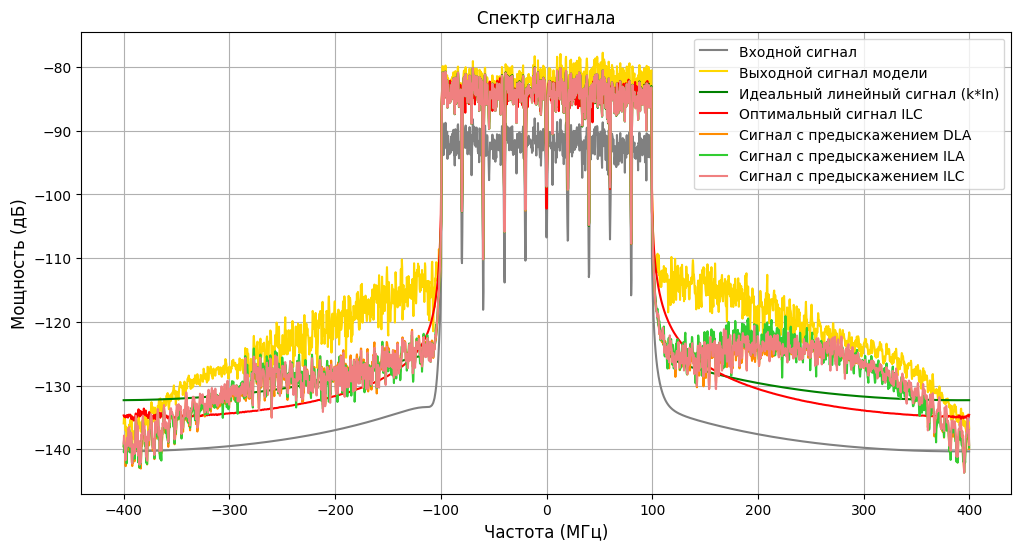

In [22]:
spectra = [
    (spectrum_y_in, 'grey', 'Входной сигнал'),
    # (spectrum_y_out, 'k', 'Выходной сигнал'),
    (spectrum_y_gmp_pa, 'gold', 'Выходной сигнал модели'),
    (spectrum_y_target, 'green', 'Идеальный линейный сигнал (k*In)'),
    # (spectrum_u_k, 'magenta', 'u_k'),
    (spectrum_u_k_pa, 'red', 'Оптимальный сигнал ILC'),
    (spectrum_y_linearized_dla_grad, 'darkorange', 'Сигнал с предыскажением DLA'),
    (spectrum_y_linearized_ila_grad, 'limegreen', 'Сигнал с предыскажением ILA'),
    (spectrum_y_linearized_ilc_grad, 'lightcoral', 'Сигнал с предыскажением ILC')
]

plotting.plot_signal_spectra(
    freqs=freqs,
    spectra=spectra,
    title='Спектр сигнала',
    xlabel='Частота (МГц)',
    ylabel='Мощность (дБ)'
)

AM/AM & AM/PM

In [49]:
y_in_am_am, y_out_am_am = metrics.calculate_am_am(y_in_tensor, y_out_tensor)
y_in_am_pm, y_in_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_out_tensor)

_, y_pa_am_am = metrics.calculate_am_am(y_in_tensor, y_gmp_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_gmp_pa)

_, y_target_am_am = metrics.calculate_am_am(y_in_tensor, y_target)
_, y_target_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_target)

# x_in_am_am, u_k_am_am = metrics.calculate_am_am(x_in_tensor, u_k)
# x_in_am_pm, u_k_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k)

# _, u_k_pa_am_am = metrics.calculate_am_am(x_in_tensor, u_k_pa)
# _, u_k_pa_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k_pa)

# dpd
_, y_dpd_dla_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_dpd_dla_grad)
_, y_dpd_dla_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_dpd_dla_grad)

_, y_dpd_ila_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_dpd_ila_grad)
_, y_dpd_ila_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_dpd_ila_grad)

_, y_dpd_ilc_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_dpd_ilc_grad)
_, y_dpd_ilc_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_dpd_ilc_grad)

#linearized
_, y_linearized_dla_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_linearized_dla_grad)
_, y_linearized_dla_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_linearized_dla_grad)

_, y_linearized_ila_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_linearized_ila_grad)
_, y_linearized_ila_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_linearized_ila_grad)

_, y_linearized_ilc_grad_am_am = metrics.calculate_am_am(y_in_tensor, y_linearized_ilc_grad)
_, y_linearized_ilc_grad_phase_am_pm = metrics.calculate_am_pm(y_in_tensor, y_linearized_ilc_grad)


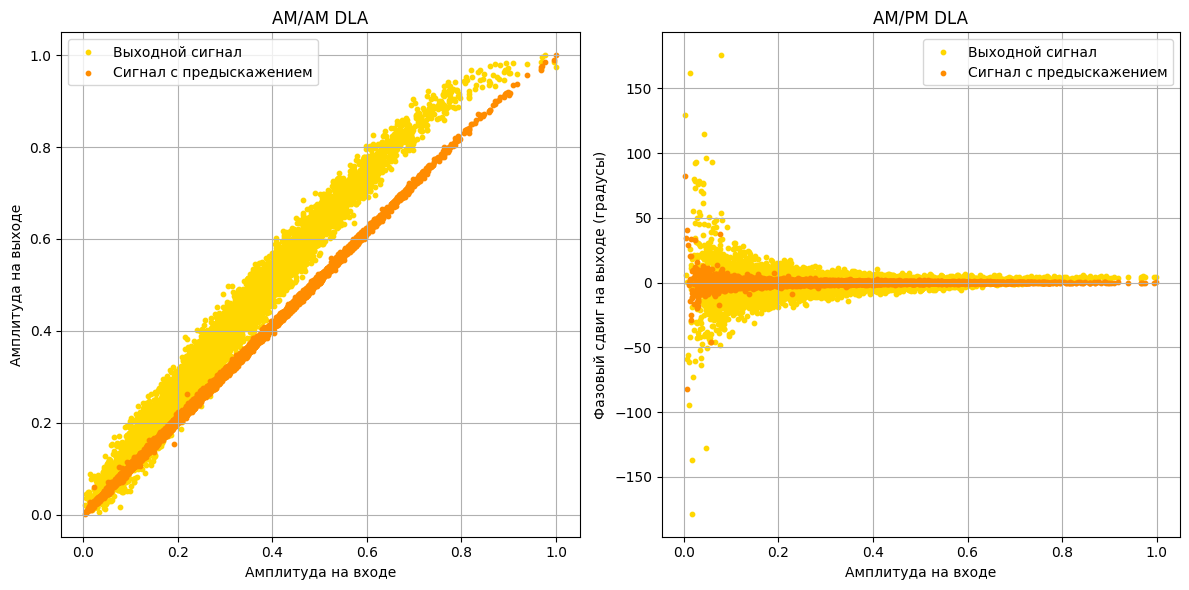

In [50]:
#DLA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_dpd_dla_grad_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_linearized_dla_grad_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_linearized_dla_grad_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



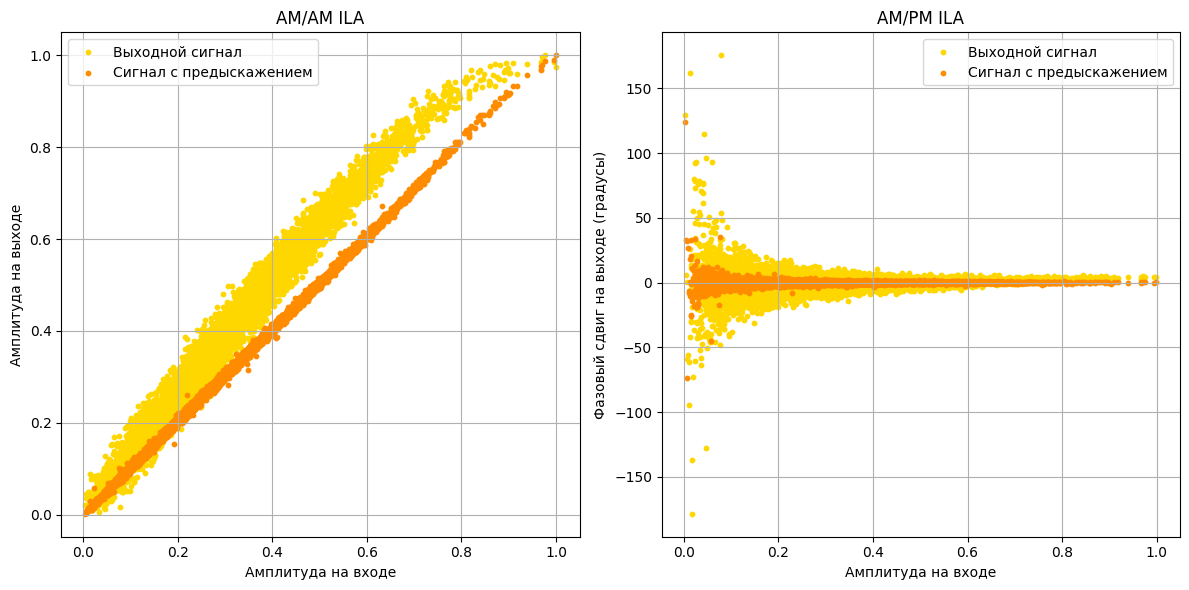

In [51]:
#ILA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_dpd_ila_grad_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_linearized_ila_grad_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_linearized_ila_grad_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILA", "AM/PM ILA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


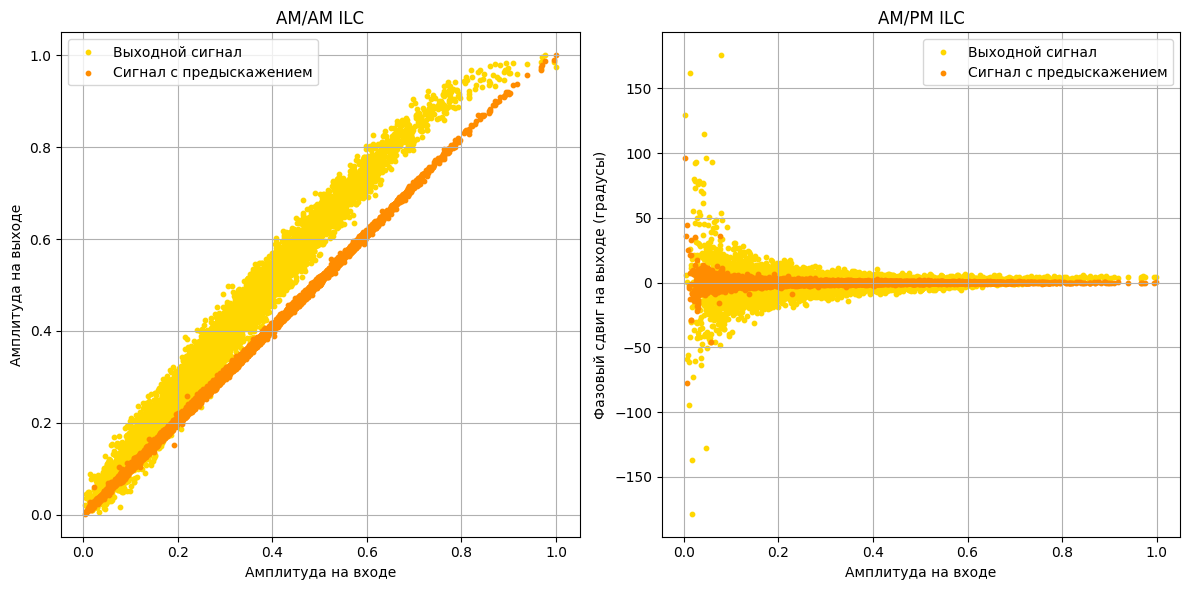

In [52]:
#ILC

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_dpd_ilc_grad_am_am, 'magenta', 'Сигнал на выходе корректора'),
    (y_in_am_am, y_linearized_ilc_grad_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_linearized_ilc_grad_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILC", "AM/PM ILC"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


Add noise

In [23]:
snr_range = list(range(20, 61, 2))

Ka = La = Kb = Lb = Mb = Kc = Lc = Mc = 3
epochs = 500
lr = 0.01
num_realizations = 10

In [ ]:
nmse_dla_list = []
acpr_left_dla_list = []
acpr_right_dla_list = []

for snr in snr_range:
    print(f"Current SNR: {snr}")

    # DLA
    dpd_dla = GMP(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, model_type="dpd_dla")
    learning.optimize_dla_grad(x_in_tensor, x_target, dpd_dla, pa_model, epochs, lr, True, snr, fs, bw_main_ch)
    y_dla_pa = pa_model.forward(dpd_dla.forward(y_in_tensor)).detach()

    nmse_dla, acpr_left_dla, acpr_right_dla = metrics.noise_realizations(num_realizations, eng, y_dla_pa, y_target, snr, fs, bw_main_ch, nperseg)
    nmse_dla_list.append(nmse_dla)
    acpr_left_dla_list.append(acpr_left_dla)
    acpr_right_dla_list.append(acpr_right_dla)


Current SNR: 20
Epoch [1/500], Loss: 0.7592251896858215
Epoch [2/500], Loss: 0.4595874845981598
Epoch [3/500], Loss: 0.20374681055545807
Epoch [4/500], Loss: 0.33480826020240784
Epoch [5/500], Loss: 0.4394076466560364
Epoch [6/500], Loss: 0.2909787595272064
Epoch [7/500], Loss: 0.14757993817329407
Epoch [8/500], Loss: 0.06859137117862701
Epoch [9/500], Loss: 0.07800476253032684
Epoch [10/500], Loss: 0.12886548042297363
Epoch [11/500], Loss: 0.15388590097427368
Epoch [12/500], Loss: 0.13708536326885223
Epoch [13/500], Loss: 0.10454341024160385
Epoch [14/500], Loss: 0.08196345716714859
Epoch [15/500], Loss: 0.07365068793296814
Epoch [16/500], Loss: 0.0709800198674202
Epoch [17/500], Loss: 0.07150136679410934
Epoch [18/500], Loss: 0.07579395174980164
Epoch [19/500], Loss: 0.0868600457906723
Epoch [20/500], Loss: 0.0928940698504448
Epoch [21/500], Loss: 0.08789139240980148
Epoch [22/500], Loss: 0.07303638756275177
Epoch [23/500], Loss: 0.0533897839486599
Epoch [24/500], Loss: 0.04400087893

In [ ]:
nmse_ila_list = []
acpr_left_ila_list = []
acpr_right_ila_list = []

for snr in snr_range:
    print(f"Current SNR: {snr}")

    nmse_values, acpr_left_values, acpr_right_values = [], [], []
    for _ in range(num_realizations):
        dpd_ila = GMP(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, model_type="dpd_ila")
        learning.optimize_ila_grad(dpd_ila, x_in_tensor, x_target, gain, epochs, lr, pa_model, True, snr, fs, bw_main_ch)
        y_ila_pa = pa_model.forward(dpd_ila.forward(y_in_tensor)).detach()

        y_noise = metrics.add_complex_noise(y_ila_pa, snr, fs, bw_main_ch)
        nmse_values.append(metrics.compute_nmse(y_noise, y_target))
        acpr_left, acpr_right = metrics.calculate_acpr(eng, y_noise, fs, bw_main_ch, nperseg)
        acpr_left_values.append(acpr_left)
        acpr_right_values.append(acpr_right)
    
    nmse_ila_list.append(sum(nmse_values)/num_realizations)
    acpr_left_ila_list.append(sum(acpr_left_values)/num_realizations)
    acpr_right_ila_list.append(sum(acpr_right_values)/num_realizations)


Current SNR: 20
Compute on pa_model
Epoch [1/500], Loss: 0.1196875125169754
Epoch [2/500], Loss: 0.04456165060400963
Epoch [3/500], Loss: 0.05062675476074219
Epoch [4/500], Loss: 0.06048906221985817
Epoch [5/500], Loss: 0.04587510973215103
Epoch [6/500], Loss: 0.02750934474170208
Epoch [7/500], Loss: 0.014231710694730282
Epoch [8/500], Loss: 0.012269838713109493
Epoch [9/500], Loss: 0.021289415657520294
Epoch [10/500], Loss: 0.028070200234651566
Epoch [11/500], Loss: 0.024837711825966835
Epoch [12/500], Loss: 0.016400013118982315
Epoch [13/500], Loss: 0.010150866582989693
Epoch [14/500], Loss: 0.008910750970244408
Epoch [15/500], Loss: 0.011376097798347473
Epoch [16/500], Loss: 0.014842823147773743
Epoch [17/500], Loss: 0.016318487003445625
Epoch [18/500], Loss: 0.014105712063610554
Epoch [19/500], Loss: 0.009896685369312763
Epoch [20/500], Loss: 0.007217573933303356
Epoch [21/500], Loss: 0.007432885933667421
Epoch [22/500], Loss: 0.008786170743405819
Epoch [23/500], Loss: 0.0091544240

In [ ]:
nmse_uk_list = []
acpr_left_uk_list = []
acpr_right_uk_list = []

nmse_ilc_list = []
acpr_left_ilc_list = []
acpr_right_ilc_list = []

for snr in snr_range:
    print(f"Current SNR: {snr}")
    # ILC + UK
    dpd_ilc = GMP(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc, model_type="dpd_ilc")
    uk = learning.ilc_signal_grad(x_in_tensor, x_target, pa_model, 500, 0.001, True, snr, fs, bw_main_ch)
    
    uk_pa = pa_model.forward(uk).detach()
    nmse_uk, acpr_left_uk, acpr_right_uk = metrics.noise_realizations(num_realizations, eng, uk_pa, x_target, snr, fs, bw_main_ch, nperseg)
    nmse_uk_list.append(nmse_uk)
    acpr_left_uk_list.append(acpr_left_uk)
    acpr_right_uk_list.append(acpr_right_uk)

    dpd_ilc.optimize_coefficients_grad(x_in_tensor, uk, epochs, lr)
    y_ilc_pa = pa_model.forward(dpd_ilc.forward(y_in_tensor)).detach()
    
    nmse_ilc, acpr_left_ilc, acpr_right_ilc = metrics.noise_realizations(num_realizations, eng, y_ilc_pa, y_target, snr, fs, bw_main_ch, nperseg)
    nmse_ilc_list.append(nmse_ilc)
    acpr_left_ilc_list.append(acpr_left_ilc)
    acpr_right_ilc_list.append(acpr_right_ilc)

Current SNR: 20
Iteration 1/500, Loss: 0.10779836773872375
Iteration 2/500, Loss: 0.10865171998739243
Iteration 3/500, Loss: 0.10616179555654526
Iteration 4/500, Loss: 0.10509596765041351
Iteration 5/500, Loss: 0.10360472649335861
Iteration 6/500, Loss: 0.10225029289722443
Iteration 7/500, Loss: 0.09919967502355576
Iteration 8/500, Loss: 0.09955509006977081
Iteration 9/500, Loss: 0.09846743196249008
Iteration 10/500, Loss: 0.096478670835495
Iteration 11/500, Loss: 0.09515917301177979
Iteration 12/500, Loss: 0.09354323148727417
Iteration 13/500, Loss: 0.09335006028413773
Iteration 14/500, Loss: 0.09128688275814056
Iteration 15/500, Loss: 0.08954286575317383
Iteration 16/500, Loss: 0.08890431374311447
Iteration 17/500, Loss: 0.0873304158449173
Iteration 18/500, Loss: 0.08648551255464554
Iteration 19/500, Loss: 0.08517985790967941
Iteration 20/500, Loss: 0.08485699445009232
Iteration 21/500, Loss: 0.08330199867486954
Iteration 22/500, Loss: 0.08137619495391846
Iteration 23/500, Loss: 0.08

In [62]:
def tensors_to_float(tensor_list):
    float_list = [t.item() for t in tensor_list]
    return float_list

nmse_dla_list = tensors_to_float(nmse_dla_list)
nmse_ila_list = tensors_to_float(nmse_ila_list)
nmse_ilc_list = tensors_to_float(nmse_ilc_list)
nmse_uk_list = tensors_to_float(nmse_uk_list)

In [64]:
print(f"snr_range = {snr_range}")
print()

print(f"nmse_dla_list = {(nmse_dla_list)}")
print(f"acpr_left_dla_list = {acpr_left_dla_list}")
print(f"acpr_right_dla_list = {acpr_right_dla_list}")
print()

print(f"nmse_ila_list = {nmse_ila_list}")
print(f"acpr_left_ila_list = {acpr_left_ila_list}")
print(f"acpr_right_ila_list = {acpr_right_ila_list}")
print()

print(f"nmse_ilc_list = {nmse_ilc_list}")
print(f"acpr_left_ilc_list = {acpr_left_ilc_list}")
print(f"acpr_right_ilc_list = {acpr_right_ilc_list}")
print()

print(f"nmse_uk_list = {nmse_uk_list}")
print(f"acpr_left_uk_list = {acpr_left_uk_list}")
print(f"acpr_right_uk_list = {acpr_right_uk_list}")

snr_range = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]

nmse_dla_list = [-14.1044340133667, -16.018064498901367, -17.97743797302246, -19.84555435180664, -21.76476287841797, -23.601543426513672, -25.397140502929688, -27.051654815673828, -28.60270118713379, -29.951904296875, -31.10137939453125, -31.99922752380371, -32.693359375, -33.20136260986328, -33.556922912597656, -33.7752571105957, -33.94951248168945, -34.041229248046875, -34.11683654785156, -34.161094665527344, -34.18443298339844]
acpr_left_dla_list = [-19.98307782854365, -22.044059761313314, -24.047040241882005, -25.981348959580895, -27.975370600038946, -29.942117343851447, -31.96514345661867, -33.80510011678665, -35.72137883607495, -37.63892721922215, -39.546686668811134, -41.14783435664147, -42.72300193647455, -44.1586403570728, -45.36636102368466, -46.3075550113637, -47.042928773938236, -47.62786795374185, -48.053632118082476, -48.26038054693791, -48.41887604347718]
acpr_right_dla_list

In [24]:
# значения в виде списков чтобы не рассчитывать снова все значения

snr_range = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]

nmse_dla_list = [-14.1044340133667, -16.018064498901367, -17.97743797302246, -19.84555435180664, -21.76476287841797, -23.601543426513672, -25.397140502929688, -27.051654815673828, -28.60270118713379, -29.951904296875, -31.10137939453125, -31.99922752380371, -32.693359375, -33.20136260986328, -33.556922912597656, -33.7752571105957, -33.94951248168945, -34.041229248046875, -34.11683654785156, -34.161094665527344, -34.18443298339844]
acpr_left_dla_list = [-19.98307782854365, -22.044059761313314, -24.047040241882005, -25.981348959580895, -27.975370600038946, -29.942117343851447, -31.96514345661867, -33.80510011678665, -35.72137883607495, -37.63892721922215, -39.546686668811134, -41.14783435664147, -42.72300193647455, -44.1586403570728, -45.36636102368466, -46.3075550113637, -47.042928773938236, -47.62786795374185, -48.053632118082476, -48.26038054693791, -48.41887604347718]
acpr_right_dla_list = [-20.041831052899113, -21.95478038014439, -23.98363774561688, -25.910596158467115, -27.91143197214374, -29.830851608311, -31.79363647332617, -33.5694401253062, -35.43604753655994, -37.07000947388168, -38.589720264578695, -39.981493718118756, -41.18240060456666, -42.0034433292463, -42.727465426518414, -43.28342016300996, -43.61496527628741, -43.81084719101566, -43.98201861121989, -44.08200476372817, -44.162913038570224]

nmse_ila_list = [-13.854040145874023, -15.777467727661133, -17.762771606445312, -19.657350540161133, -21.58496856689453, -23.4307918548584, -25.17462730407715, -26.818567276000977, -28.340505599975586, -29.61135482788086, -30.697265625, -31.556087493896484, -32.22067642211914, -32.64470291137695, -32.968238830566406, -33.183040618896484, -33.31875991821289, -33.422943115234375, -33.47233963012695, -33.510684967041016, -33.5294189453125]
acpr_left_ila_list = [-20.027768364406164, -22.02595135920506, -23.98453820660988, -25.961216816485567, -27.89464166886246, -29.93190200512903, -31.88604293318803, -33.82673998661604, -35.772038392214476, -37.61613725169961, -39.35554674161212, -40.999545012141596, -42.574679365583734, -43.93042452256015, -45.03867510014294, -45.908987401819914, -46.56702971768967, -47.03977254628908, -47.41264367177677, -47.67963051393086, -47.772995960135724]
acpr_right_ila_list = [-19.930579122305584, -21.869039603483063, -23.92589430272745, -25.8934186825347, -27.89435768624694, -29.824054115245037, -31.657192539039386, -33.574507705349546, -35.29508665583067, -36.91289391444029, -38.35332621280914, -39.531460585547265, -40.53575407057057, -41.37233528658536, -41.93340984815785, -42.33601701225255, -42.63072372715388, -42.78626262772036, -42.906565042070014, -42.98986099019487, -43.06106380151427]

nmse_ilc_list = [-14.0765962600708, -16.038497924804688, -17.95038604736328, -19.846113204956055, -21.75259017944336, -23.631811141967773, -25.368045806884766, -27.051647186279297, -28.601642608642578, -29.968273162841797, -31.0953426361084, -32.05195999145508, -32.759464263916016, -33.242897033691406, -33.58929443359375, -33.86418914794922, -34.00400924682617, -34.103553771972656, -34.197731018066406, -34.209129333496094, -34.251609802246094]
acpr_left_ilc_list = [-19.987904634237463, -22.032664265763948, -23.981805945312637, -25.985078180439405, -27.97285318573928, -29.932254292413706, -31.93950622504634, -33.871982256476386, -35.687000986372624, -37.643129058194496, -39.36068479051006, -41.063457267103004, -42.61319314281078, -43.93533817262031, -45.077593707598375, -46.05866500876228, -46.68572673296391, -47.206334708000576, -47.541040851625766, -47.77248651232119, -47.95394808902196]
acpr_right_ilc_list = [-19.970945068810845, -21.99232485637614, -23.99870022329292, -25.8777047238745, -27.85245425738548, -29.870087979042914, -31.71947716771799, -33.548264032512904, -35.38769115623252, -36.93997367595692, -38.44486643405877, -39.832029876134314, -40.894418612291034, -41.675168206028694, -42.37802985442333, -42.748574412828496, -43.07917614846056, -43.318133130296104, -43.473543736876735, -43.543050561279685, -43.59642567165372]

nmse_uk_list = [-14.0831298828125, -16.007923126220703, -17.956777572631836, -19.8975887298584, -21.878353118896484, -23.844219207763672, -25.788644790649414, -27.7381649017334, -29.701080322265625, -31.64846420288086, -33.609657287597656, -35.53433609008789, -37.480770111083984, -39.428749084472656, -41.34610366821289, -43.275142669677734, -45.19207000732422, -47.10540771484375, -48.99323654174805, -50.86845397949219, -52.7203369140625]
acpr_left_uk_list = [-19.998392505893012, -21.96503696465798, -23.970991167027375, -25.9149880083065, -27.92604114808463, -29.87986846158727, -31.819333935519474, -33.75500066095982, -35.68040463397734, -37.580494422986966, -39.43423352610119, -41.25160083392008, -42.91737743348149, -44.5111827081357, -45.92210941660184, -47.14031506566594, -48.14644265515601, -48.92050801676599, -49.54857485864436, -49.93755700347053, -50.273354378725]
acpr_right_uk_list = [-19.893920065196465, -21.86624051842887, -23.84565607408318, -25.75388263544563, -27.70074723690906, -29.627564553190144, -31.569643994482238, -33.43726278691267, -35.32040951826972, -37.142184428452595, -38.9831850829623, -40.66346961805266, -42.32750364604643, -43.85724713876513, -45.296073869065694, -46.486982373361776, -47.48990958237207, -48.29148483835154, -48.9249656987649, -49.38223862798154, -49.67895177822955]

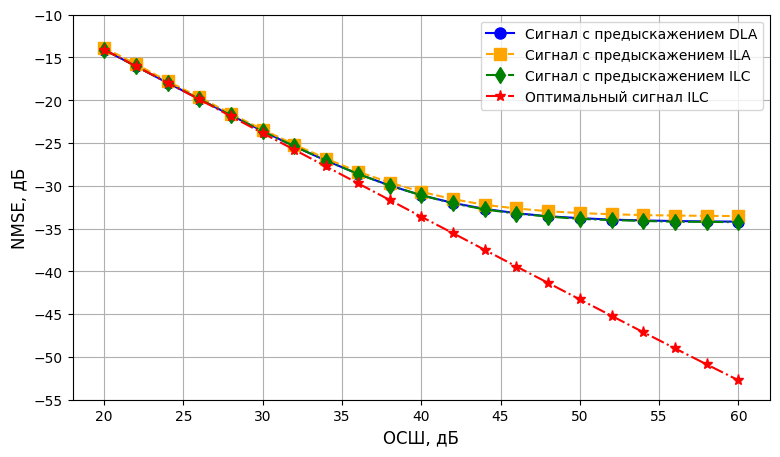

In [25]:
markersize = 8
plt.figure(figsize=(9, 5))
plt.plot(snr_range, nmse_dla_list,color='blue', linestyle='-', label="Сигнал с предыскажением DLA",
         marker='o', markersize=markersize)
plt.plot(snr_range, nmse_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA",
         marker='s', markersize=markersize)
plt.plot(snr_range, nmse_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC",
         marker='d', markersize=markersize)
plt.plot(snr_range, nmse_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC",
         marker='*', markersize=markersize)

plt.xlabel("ОСШ, дБ", fontsize=12)
plt.ylabel("NMSE, дБ", fontsize=12)
# plt.title("Зависимость NMSE от ОСШ")
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -9, 5))
plt.legend()
plt.grid(True)

plt.show()


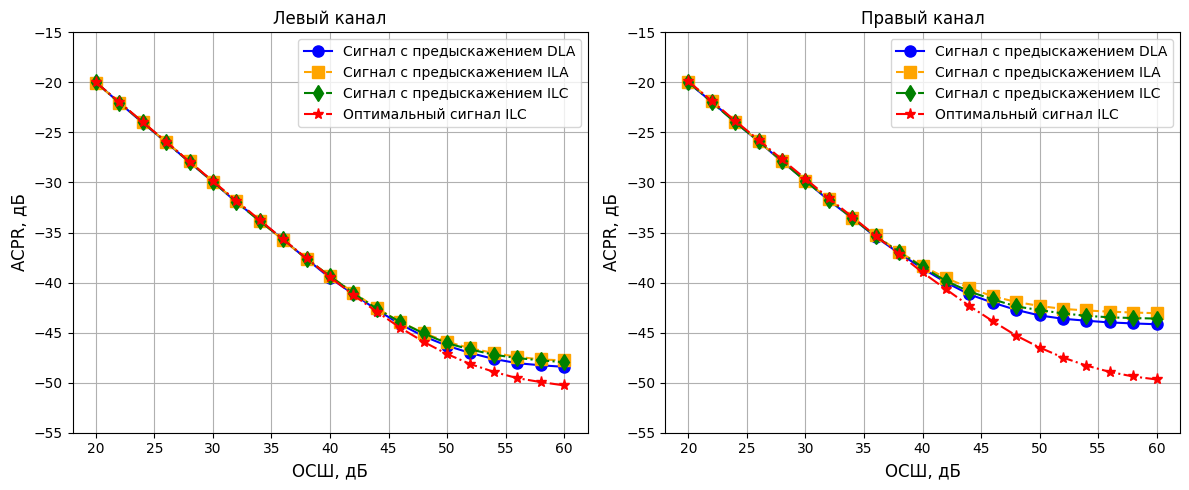

In [26]:
markersize=8
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# plt.plot(snr_range, acpr_left_dla_list, marker='o', color='blue', linestyle='-', label="Сигнал с предыскажением DLA")
# plt.plot(snr_range, acpr_left_ila_list, marker='s', color='orange', linestyle='--', label="Сигнал с предыскажением ILA")
# plt.plot(snr_range, acpr_left_ilc_list, marker='d', color='green', linestyle='-.', label="Сигнал с предыскажением ILC")
# plt.plot(snr_range, acpr_left_uk_list, marker='*', color='indigo', linestyle='-.', label="Оптимальный сигнал ILC")
plt.plot(snr_range, acpr_left_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_left_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_left_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_left_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Левый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(snr_range, acpr_right_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_right_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_right_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_right_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Правый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
eng.quit()